In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!unzip "/content/drive/MyDrive/EuroSAT.zip" -d "/content/EuroSAT"

Streaming output truncated to the last 5000 lines.
  inflating: /content/EuroSAT/allBands/River/River_1990.tif  
  inflating: /content/EuroSAT/allBands/River/River_1991.tif  
  inflating: /content/EuroSAT/allBands/River/River_1992.tif  
  inflating: /content/EuroSAT/allBands/River/River_1993.tif  
  inflating: /content/EuroSAT/allBands/River/River_1994.tif  
  inflating: /content/EuroSAT/allBands/River/River_1995.tif  
  inflating: /content/EuroSAT/allBands/River/River_1996.tif  
  inflating: /content/EuroSAT/allBands/River/River_1997.tif  
  inflating: /content/EuroSAT/allBands/River/River_1998.tif  
  inflating: /content/EuroSAT/allBands/River/River_1999.tif  
  inflating: /content/EuroSAT/allBands/River/River_2.tif  
  inflating: /content/EuroSAT/allBands/River/River_20.tif  
  inflating: /content/EuroSAT/allBands/River/River_200.tif  
  inflating: /content/EuroSAT/allBands/River/River_2000.tif  
  inflating: /content/EuroSAT/allBands/River/River_2001.tif  
  inflating: /content/Eur

In [6]:
import os
print(os.listdir("/content/EuroSAT"))

['Forest', 'Pasture', 'label_map.json', 'River', 'Residential', 'validation.csv', 'train.csv', 'allBands', 'HerbaceousVegetation', 'test.csv', 'PermanentCrop', 'Industrial', 'AnnualCrop', 'Highway', 'SeaLake']


In [8]:
#Filter Only Class Folders
import os

data_dir = "/content/EuroSAT"
classes = []

for item in os.listdir(data_dir):
    path = os.path.join(data_dir, item)
    if os.path.isdir(path) and item != "allBands":
        classes.append(item)

print("Classes:", classes)
print("Number of classes:", len(classes))
# folder name = label
#images inside = data only need this , Forest/ → label = "Forest"
#River/ → label = "River" only getting the labels

Classes: ['Forest', 'Pasture', 'River', 'Residential', 'HerbaceousVegetation', 'PermanentCrop', 'Industrial', 'AnnualCrop', 'Highway', 'SeaLake']
Number of classes: 10


In [9]:
# Connect Notebook to Your src File

In [15]:
# dataloader .ipyb-->.py
%%writefile /content/drive/MyDrive/satellite-land-cover/src/data_loader.py

import os
import cv2
import numpy as np

def load_images(data_dir, limit_per_class=200, img_size=(64, 64)):
    images = []
    labels = []

    for cls in os.listdir(data_dir):
        class_path = os.path.join(data_dir, cls)

        if not os.path.isdir(class_path) or cls == "allBands":
            continue

        count = 0

        for img_name in os.listdir(class_path):
            if count >= limit_per_class:
                break

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)
            img = cv2.resize(img, img_size)

            images.append(img)
            labels.append(cls)

            count += 1

    return np.array(images), np.array(labels)

Writing /content/drive/MyDrive/satellite-land-cover/src/data_loader.py


In [16]:
import sys
sys.path.append('/content/drive/MyDrive/satellite-land-cover')

In [11]:
import os
print(os.listdir('/content/drive/MyDrive/satellite-land-cover'))

['src']


In [12]:
print(os.listdir('/content/drive/MyDrive/satellite-land-cover/src'))

['data_loader.ipynb']


In [17]:
# import the function
from src.data_loader import load_images

In [18]:
# Call the function
X, y = load_images(data_dir, limit_per_class=200)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 64, 64, 3)
y shape: (2000,)


In [ ]:
#Variable	Meaning
#X	-->images (features)
#y	-->class label

In [20]:
# save the data
import numpy as np

np.save("/content/drive/MyDrive/satellite-land-cover/X.npy", X)
np.save("/content/drive/MyDrive/satellite-land-cover/y.npy", y)

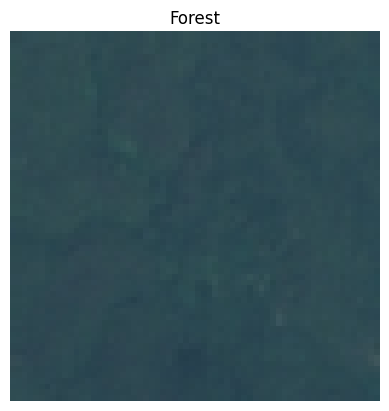

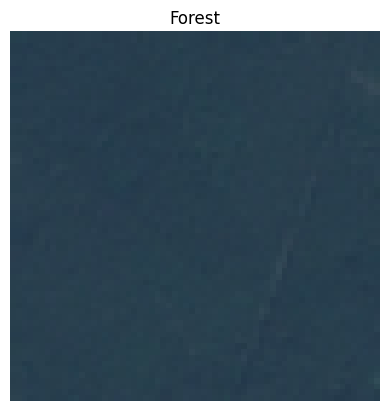

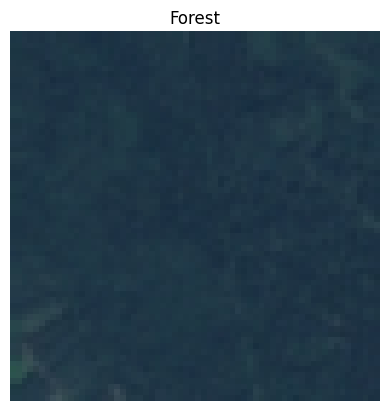

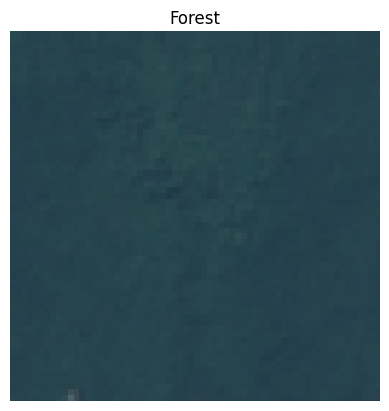

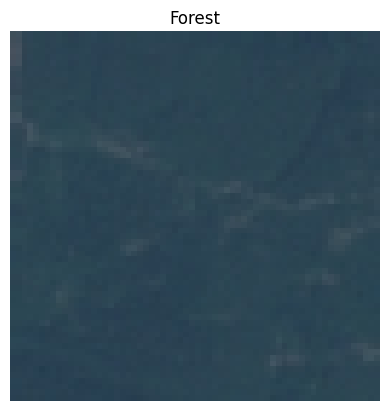

In [19]:
# Verify the data
import matplotlib.pyplot as plt
import cv2

for i in range(5):
    plt.imshow(cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB))
    plt.title(y[i])
    plt.axis('off')
    plt.show()

In [ ]:
### Summary
#- Dataset loaded from Google Drive
#- 10 land cover classes identified
#- Images successfully visualized
#- Data converted into X (images) and y (labels)
#- Verified data correctness